# Tutorial

In [1]:
import sys
import os
from pathlib import Path
import json
import math
import matplotlib.pyplot as plt

# %ls
%cd ../

import predict
import load_data
import plot_prediction

%cd ../

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu


I0000 00:00:1788516378.482488  396452 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788516378.482906  396452 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788516378.524437  396452 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788516379.719766  396452 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [2]:
PARAMETER_ORDER = [
    'Omega_m',
    'bary_Mc',
    'bary_nu',
    'sigma8',
    'w0',
    'n_s',
    'Omega_b',
    'H0',
]

Firt of all let's create two datasets: one with the training and validating simulations and one

In [ ]:
%run emu/build_dataset.py

Let's now train the emulator. 
Note: this saves the models, so there's no need to re-run it unless you want to change the dataset.

In [ ]:
%run emu/train.py

Once the emulator is trained, we can make some predictions. Here we're using some of the CosmoGRID simulations to make the prediction (these have been saved separately when running ``build_dataset.py`` and not been used in the training).

In [3]:
# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

sep_bin_center = metadata['sep_bin_center']

# choose two simulations indices to plot against prediction
idx1 = 0
idx2 = 47

E0000 00:00:1788516383.248764  396452 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step


/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu/plot_prediction.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step
77/77 - 0s - 2ms/step


/tmp/ipykernel_396452/1405959449.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because non

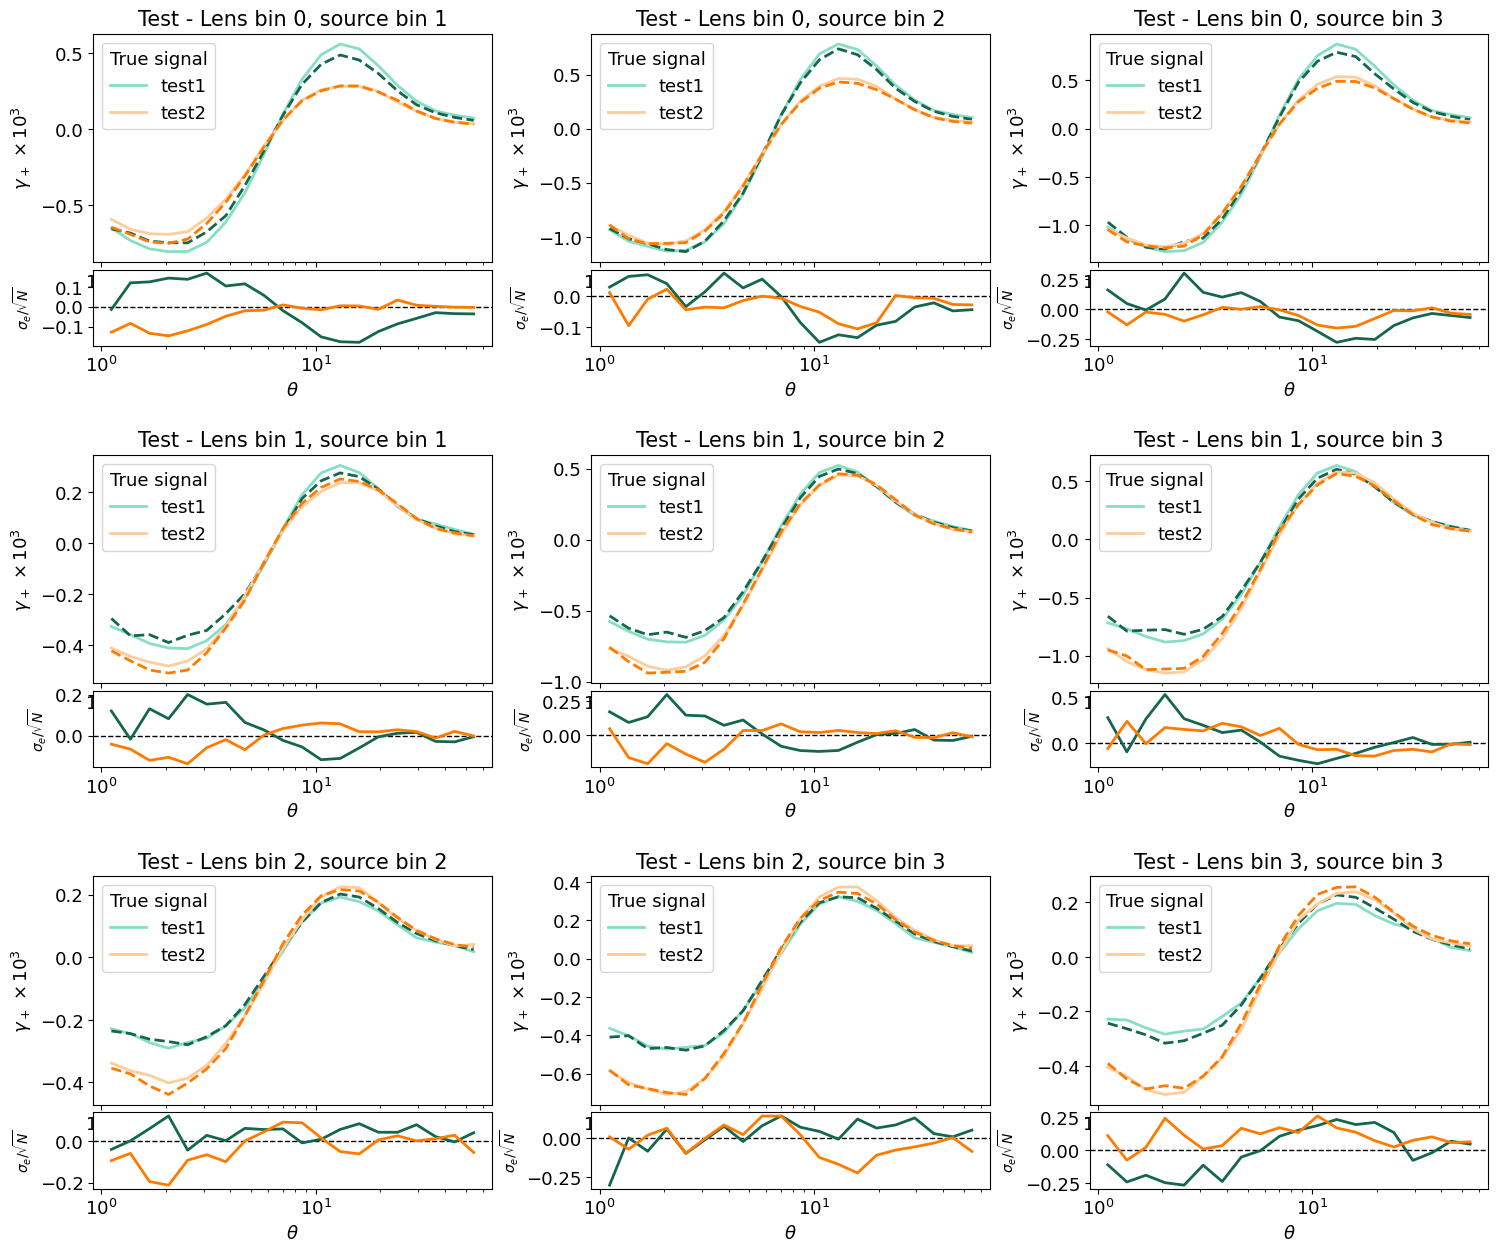

In [4]:
# big plot with multiple subplots, each one having a different bin pair (lens, source)
all_pairs = metadata["bin_pairs"]
ncols = 3
nrows = math.ceil(len(all_pairs) / ncols)
fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
outer_grid = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.25)

for panel_idx, (l, s) in enumerate(all_pairs):
    row = panel_idx // ncols
    col = panel_idx % ncols
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax0 = fig.add_subplot(inner_grid[0])
    ax1 = fig.add_subplot(inner_grid[1], sharex=ax0)

    model_path = 'emu/models/lens' + str(l) + '_source' + str(s) + '.keras'
    X_test, Y_test, shape_noise = load_data.load_dataset(l, s)

    # create dictionary with values of X_test
    params_dict = {par: X_test[:, i] for i, par in enumerate(PARAMETER_ORDER)}
    prediction = predict.make_prediction(params_dict, l, s, model_path)

    plot_prediction.plot_prediction_shapenoise(
        xarr=sep_bin_center,
        predicted_signal=prediction,
        true_signal=Y_test,
        shape_noise=shape_noise,
        l=l,
        s=s,
        idx1=idx1,
        idx2=idx2,
        xlabel=r'$\theta$',
        ylabel=r'$\gamma_+\, \times10^3$',
        legend=['test1', 'test2'],
        title=f'Test - Lens bin {l}, source bin {s}',
        ax0=ax0,
        ax1=ax1,
        save=False,
        savename='all_bins.pdf'
    )

# hide any unused panels if the grid is larger than the number of bin pairs
for panel_idx in range(len(all_pairs), nrows * ncols):
    row = panel_idx // ncols
    col = panel_idx % ncols
    fig.add_subplot(outer_grid[row, col]).axis('off')

fig.tight_layout()
plt.show()

In [ ]:
print('Cosmological parameters of the two selected simulations:')
name_list = ['bary_Mc', 'bary_nu', 'H0', 'Ob', 'Om', 'ns', 's8', 'w0']
# create dictionary with names as in name_list and X_test[0,:] as values
dict = {name: X_test[idx1, i] for i, name in enumerate(name_list)}
print(f'Simulation {idx1}: {dict}')
dict = {name: X_test[idx2, i] for i, name in enumerate(name_list)}
print(f'Simulation {idx2}: {dict}')

### Tests on training -- loss function

In [ ]:
import pickle  

# Loading the history object
with open('emu/models/traing_history0_source1.pkl', 'rb') as file:
    loaded_history = pickle.load(file)

# mean square error
# mse_training = loaded_history['mse']
# mse_verify = loaded_history['val_mse']
# loss 
training_loss = loaded_history['loss']
validation_loss = loaded_history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('MSE and loss of Training and Verification', fontsize=15)

# ax[0].plot(mse_training, color='#8AD2E8', linewidth=2)
# ax[0].plot(mse_verify, linestyle='dashed', color="#0C536B", linewidth=2)
ax[0].set_ylabel('MSE', fontsize=13)
ax[0].set_xlabel('Epochs', fontsize=13)
ax[0].legend(['Training', 'Verification'], loc='upper right', fontsize=13)

ax[1].plot(training_loss, color='#8AD2E8', linewidth=2)
ax[1].plot(validation_loss, linestyle='dashed', color="#0C536B", linewidth=2)
ax[1].set_ylabel('Loss', fontsize=13)
ax[1].set_xlabel('Epochs', fontsize=13)
ax[1].legend(['Training', 'Verification'], loc='upper right', fontsize=13)

plt.tight_layout()

I don't exactly know what this is 

In [ ]:
# Import the useful tools for plotting a confusion matrix
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix
import numpy as np
prediction = predict.make_prediction(X_test, l, s, model_path)

# Convert these to single numerical predictions
xg_cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(prediction, axis=1))

In [ ]:
# print(Y_test.shape)
print(np.argmax(Y_test, axis=1))
print(np.argmax(prediction, axis=1))
print(xg_cm)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Plot the confusion matrix using a heatmap
sns.heatmap(xg_cm, annot=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Regular)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot the confusion matrix using a heatmap and use a LogNorm normalise
sns.heatmap(xg_cm, annot=False, cmap='Blues', norm=LogNorm(), ax=axes[1])
axes[1].set_title('Confusion Matrix (LogNorm)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()